In [1]:
from matplotlib import pyplot as plt
from itertools import product
import pandas as pd
import os.path as op
import argparse
import re
import numpy as np
import seaborn as sns
from util.io.ffr import *

# EEG
import mne
from bids import BIDSLayout

# Cluster test
from mne_ari import all_resolutions_inference
from mne.viz import plot_topomap, plot_evoked_topomap
from mne.channels import find_ch_adjacency
from mne.stats import permutation_cluster_1samp_test, permutation_cluster_test, combine_adjacency
from scipy.stats import ttest_rel
import pickle

In [2]:
def read_epochs(sub, desc):
    '''
    reads and concatenates epochs across runs
    '''
    from bids import BIDSLayout
    layout = BIDSLayout(BIDS_ROOT, derivatives = True)
    run = lambda f: int(re.findall('run-(\w+)_', f)[0])
    fnames = layout.get(
        return_type = 'filename',
        subject = sub, 
        desc = desc
        )
    print(fnames)
    fnames.sort(key = run)
    epochs_all = [mne.read_epochs(f) for f in fnames]
    for epochs in epochs_all:
        print(epochs.info['sfreq'])
    epochs = mne.concatenate_epochs(epochs_all)
    epochs = epochs.pick('eeg')
    return epochs

### 1 Sample clusters for target vs nontarget

In [3]:
# # Load epochs and average into evoked objects
# BIDS_ROOT = '../data/bids'
# layout = BIDSLayout(BIDS_ROOT, derivatives = True, regex_search = 'forERPall')
# subs = layout.get_subjects(scope = 'erp')
# subs.sort(key = int)

# evokeds_target = []
# evokeds_nontarget = []

# for sub in subs:
#     if int(sub) == 43:
#         continue
    
#     # Read epochs
#     epochs = read_epochs(sub, 'forERPall')
#     epochs = epochs.shift_time(tshift = -0.2262, relative = False)
    
#     # Created evoked object
#     evokeds_target.append(epochs['11', '22', '33'].average())
#     evokeds_nontarget.append(epochs['12', '13', '21', '23', '31', '32'].average())

In [2]:
# # Extract arrays
# X_target = np.array([evk.data for evk in evokeds_target]) # (n_subjects, n_channels, n_times)
# X_nontarget = np.array([evk.data for evk in evokeds_nontarget])
# X_diff = X_target - X_nontarget

# # Build spatio-temporal adjacency
# n_subj, n_chan, n_times = X_target.shape
# adjacency = combine_adjacency(n_chan, n_times)

# # Run cluster test (within-subject A vs B)
# T_obs, clusters, p_vals, H0 = permutation_cluster_1samp_test(
#     X_diff,
#     n_permutations=5000,
#     tail=0,
#     adjacency=adjacency,
#     out_type='mask'
# )

# # Save
# with open('clusters-target.pkl', 'wb') as f:
#     pickle.dump([T_obs, clusters, p_vals, evokeds_target, evokeds_nontarget], f)

with open('clusters-target.pkl', 'rb') as f:  
    T_obs, clusters, p_vals, evokeds_target, evokeds_nontarget = pickle.load(f)

Identifying common channels ...
Identifying common channels ...
No projector specified for this dataset. Please consider the method self.add_proj.


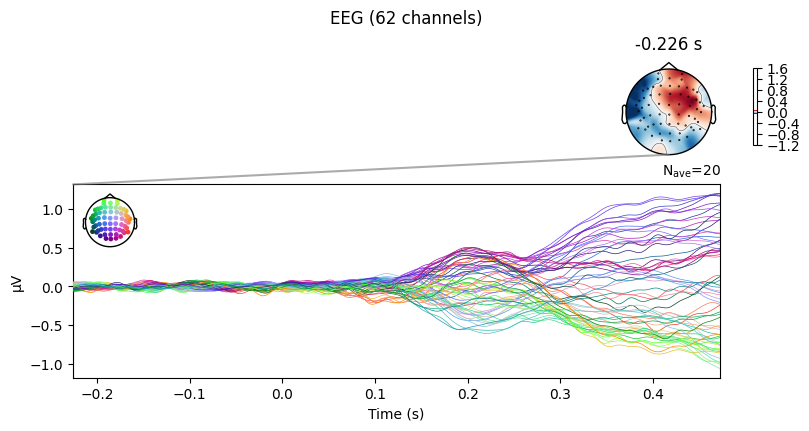

In [3]:
# Plot grand-average waveform
evoked_target_ga = mne.grand_average(evokeds_target)
evoked_nontarget_ga = mne.grand_average(evokeds_nontarget)
diff = mne.combine_evoked([evoked_target_ga, evoked_nontarget_ga], weights=[1, -1])
fig = diff.plot_joint(times = -0.226)
fig.savefig('../figs/butterfly-target.png', dpi = 300)

In [25]:
# Get clusters from mne-ari
X_target = np.array([evk.data for evk in evokeds_target]) # (n_subjects, n_channels, n_times)
X_nontarget = np.array([evk.data for evk in evokeds_nontarget])
X_diff = X_target - X_nontarget
p_vals_ari, tdp, clusters_ari = all_resolutions_inference(X_diff, alpha = 0.0464)
print(np.shape(clusters_ari))

# with open('ari-clusters-target.pkl', 'wb') as f:
#     pickle.dump([p_vals_ari, tdp, clusters_ari], f)

# with open('ari-clusters-target.pkl', 'rb') as f:  
#     p_vals_ari, tdp, clusters_ari  = pickle.load(f)

(22, 62, 700)


No projector specified for this dataset. Please consider the method self.add_proj.


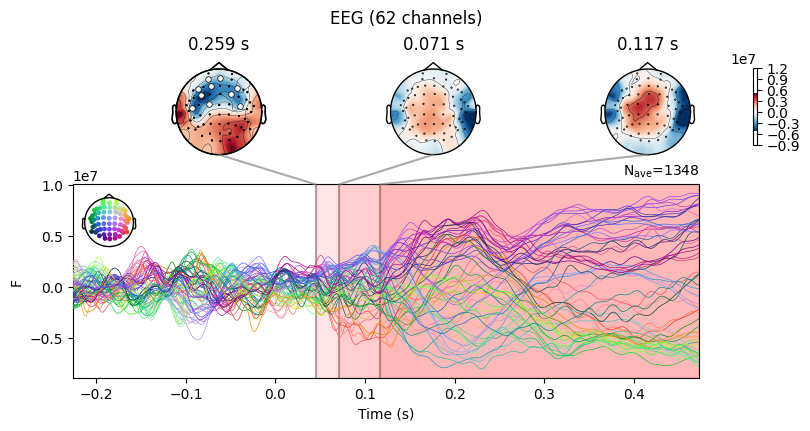

In [28]:
# Create evoked object from test-statistics
ts = evokeds_target[0]
ts.data = T_obs

# Identify significant clusters
alpha = 0.05
sig_clusters = np.array([99, 12, 75])

# chan_masks = []
sig_times = []
t_starts = []

for idx in sig_clusters:
    mask = clusters[idx]              # shape = (n_channels, n_times)
    time_mask = mask.any(axis=0)      # True at timepoints belonging to the cluster

    # Extract start/end times (contiguous segments)
    cluster_times = ts.times[time_mask]
    t_start, t_end = cluster_times[0], cluster_times[-1]
    midpoint = (t_start + t_end)/2
    
    t_starts.append(t_start)
    sig_times.append((t_start, midpoint, t_end))

# Plot channel traces
fig = ts.plot_joint(times = t_starts, show = False)
main_ax = fig.axes[len(t_starts)]
main_ax.set_ylabel('F')

# Plot the time windows
for (t_start, midpoint, t_end) in sig_times:
    main_ax.axvspan(t_start, t_end, color='red', alpha=0.1)

# Plot the topomap, do it serially because mne is annoying
i = 0
midpoint = sig_times[i][1]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[i]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )
i = 1
midpoint = sig_times[i][1]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[i]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )
i = 2
midpoint = sig_times[i][1]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[i]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )

fig.savefig('../figs/butterfly-t-target.png', dpi = 300)

In [11]:
mask = clusters_ari[0]
time_mask = mask.any(axis=0)      # True at timepoints belonging to the cluster
cluster_times = ts.times[time_mask]
t_start, t_end = cluster_times[0], cluster_times[-1]
midpoint = (t_start + t_end)/2
midpoint

0.4638

In [ ]:
# Create evoked object from test-statistics
ts = evokeds_target[0]
ts.data = T_obs

# Identify significant clusters
alpha = 0.05
# sig_clusters = np.array([99, 12, 75])

# chan_masks = []
sig_times = []
t_starts = []

for idx in sig_clusters:
    mask = clusters[idx]              # shape = (n_channels, n_times)
    time_mask = mask.any(axis=0)      # True at timepoints belonging to the cluster

    # Extract start/end times (contiguous segments)
    cluster_times = ts.times[time_mask]
    t_start, t_end = cluster_times[0], cluster_times[-1]
    midpoint = (t_start + t_end)/2
    
    t_starts.append(t_start)
    sig_times.append((t_start, midpoint, t_end))

# Plot channel traces
fig = ts.plot_joint(times = t_starts, show = False)
main_ax = fig.axes[len(t_starts)]
main_ax.set_ylabel('F')

# Plot the time windows
for (t_start, midpoint, t_end) in sig_times:
    main_ax.axvspan(t_start, t_end, color='red', alpha=0.1)

# Plot the topomap, do it serially because mne is annoying
i = 0
midpoint = sig_times[i][0]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[i]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )
i = 1
midpoint = sig_times[i][1]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[i]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )
i = 2
midpoint = sig_times[i][1]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[i]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )

# fig.savefig('../figs/butterfly-t-target.png', dpi = 300)

In [106]:
for idx in sig_clusters:
    cluster = clusters[idx]                    # (n_channels, n_times)
    chan_mask = cluster.any(axis=1)            # collapse across time
    n_electrodes = chan_mask.sum()
    which_electrodes = np.where(chan_mask)[0]

    print(f"Cluster {idx}:")
    print(f"p {p_vals[idx]}")
    print(f"  Number of electrodes: {n_electrodes}")
    print(f"  Electrodes: {which_electrodes}")

Cluster 99:
p 0.0002
  Number of electrodes: 16
  Electrodes: [23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38]
Cluster 12:
p 0.0002
  Number of electrodes: 13
  Electrodes: [10 11 12 13 14 15 16 17 18 19 20 21 22]
Cluster 75:
p 0.0004
  Number of electrodes: 9
  Electrodes: [0 1 2 3 4 5 6 7 8]


## Between subjects clusters by accuracy

In [70]:
# # Load accuracies to add to data
# accuracy = pd.read_csv('accuracy.csv', index_col = 0)
# med = np.median(accuracy.accuracy)
# low_subs = list(accuracy.subject[accuracy.accuracy < med])
# high_subs = list(accuracy.subject[accuracy.accuracy > med])

In [69]:
# # Load epochs and average into evoked objects
# BIDS_ROOT = '../data/bids'
# layout = BIDSLayout(BIDS_ROOT, derivatives = True, regex_search = 'forERPall')
# subs = layout.get_subjects(scope = 'erp')
# subs.sort(key = int)

# evokeds_low = []
# evokeds_high = []

# for sub in subs:
#     if int(sub) == 43:
#         continue
    
#     epochs = read_epochs(sub, 'forERPall')
#     epochs = epochs.shift_time(tshift = -0.2262, relative = False)

#     if int(sub) in low_subs:
#         evokeds_low.append(epochs['11', '22', '33'].average())
#     else:
#         evokeds_high.append(epochs['12', '13', '21', '23', '31', '32'].average())

In [107]:
# # Extract arrays
# X_low = np.array([evk.data for evk in evokeds_low]) # (n_subjects, n_channels, n_times)
# X_high = np.array([evk.data for evk in evokeds_high])
# X = [X_low, X_high]

# # Build spatio-temporal adjacency
# n_subj, n_chan, n_times = X_low.shape
# adjacency = combine_adjacency(n_chan, n_times)

# # Run cluster test (within-subject A vs B)
# T_obs, clusters, p_vals, H0 = permutation_cluster_test(
#     X,
#     n_permutations=5000,
#     tail=0,
#     adjacency=adjacency,
#     out_type='mask'
# )

# # Save
# with open('clusters-accuracy.pkl', 'wb') as f:
#     pickle.dump([T_obs, clusters, p_vals, evokeds_low, evokeds_high], f)

with open('clusters-accuracy.pkl', 'rb') as f:  
    T_obs, clusters, p_vals, evokeds_low, evokeds_high = pickle.load(f)

Identifying common channels ...
Identifying common channels ...
No projector specified for this dataset. Please consider the method self.add_proj.


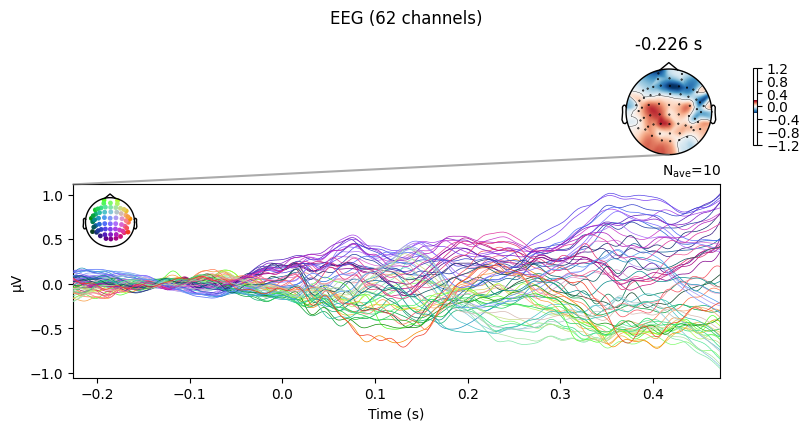

In [97]:
# Plot grand-average waveform
evoked_low_ga = mne.grand_average(evokeds_low)
evoked_high_ga = mne.grand_average(evokeds_high)
diff = mne.combine_evoked([evoked_low_ga, evoked_high_ga], weights=[1, -1])
fig = diff.plot_joint(times = [-0.226])
fig.savefig('../figs/butterfly-accuracy.png', dpi = 300)

No projector specified for this dataset. Please consider the method self.add_proj.


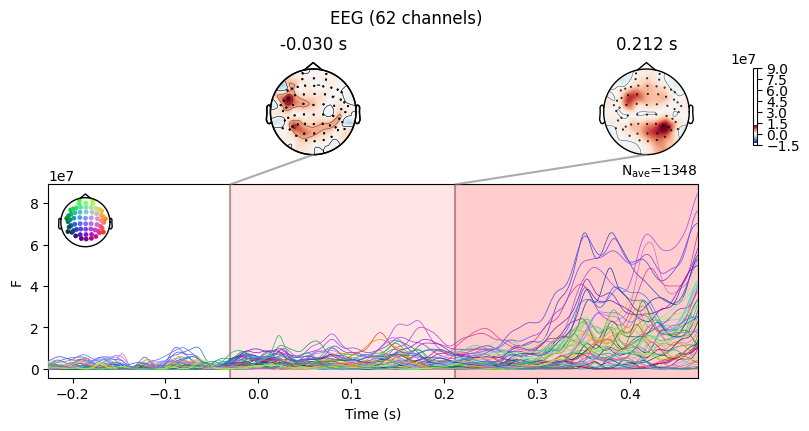

In [109]:
# Create evoked object from test-statistics
ts = evokeds_low[0]
ts.data = T_obs

# Identify significant clusters
alpha = 0.05
sig_clusters = np.array([12, 1])

sig_times = []
t_starts = []

for idx in sig_clusters:
    mask = clusters[idx]              # shape = (n_channels, n_times)
    time_mask = mask.any(axis=0)      # True at timepoints belonging to the cluster

    # Extract start/end times (contiguous segments)
    cluster_times = ts.times[time_mask]
    t_start, t_end = cluster_times[0], cluster_times[-1]
    midpoint = (t_start + t_end)/2
    
    t_starts.append(t_start)
    sig_times.append((t_start, midpoint, t_end))

# Plot channel traces
fig = ts.plot_joint(times = t_starts, show = False)
main_ax = fig.axes[len(t_starts)]
main_ax.set_ylabel('F')

# Plot the time windows
for (t_start, midpoint, t_end) in sig_times:
    main_ax.axvspan(t_start, t_end, color='red', alpha=0.1)

# Plot the topomap, do it serially because mne is annoying
i = 0
midpoint = sig_times[i][0]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[1]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )
i = 1
midpoint = sig_times[i][1]
ts.plot_topomap(
    times = midpoint,
    axes = fig.axes[i],
    mask = clusters[sig_clusters[0]],
    colorbar = False,
    mask_params = {'markersize': 8},
    scalings = 1.,
    )

fig.savefig('../figs/butterfly-t-accuracy.png', dpi = 300)

In [110]:
for idx in sig_clusters:
    cluster = clusters[idx]                    # (n_channels, n_times)
    chan_mask = cluster.any(axis=1)            # collapse across time
    n_electrodes = chan_mask.sum()
    which_electrodes = np.where(chan_mask)[0]

    print(f"Cluster {idx}:")
    print(f"p {p_vals[idx]}")
    print(f"  Number of electrodes: {n_electrodes}")
    print(f"  Electrodes: {which_electrodes}")

Cluster 12:
p 0.0002
  Number of electrodes: 14
  Electrodes: [ 9 10 11 12 13 14 15 16 17 18 19 20 21 22]
Cluster 1:
p 0.0016
  Number of electrodes: 8
  Electrodes: [0 1 2 3 4 5 6 7]


In [113]:
np.shape(clusters_ari)

(24, 62, 700)